# KD-дерево для ускорения kNN

Реализовать собственное KD-дерево: рекурсивно разбивать пространство по координатным осям, а при запросе просматривать только те ветви, которые могут содержать ближайших соседей. Сравнить количество вычисляемых расстояний и время работы с полным перебором и проверить, при какой размерности преимущество KD-дерева начинает исчезать.

Обучающие и тестовые точки равномерно генерируются внутри блока $[-10, 10]^d$. К тестовым точкам добавляется небольшой нормальный шум с $\sigma=0.1$. Также фиксируем seed рандома.

Проведём несколько экспериментов, в каждом из которых будем фиксировать все парметры кроме одного и сравнивать две реализации: абсолютное значение - разница во времени выполнения, относительное - разница в количестве точек, до которых посчитали расстояние (тут больше интерес к реализации kd-дерева, потому что тупняк во всех экспериментах кроме одного даст фиксированный результат).

#### Перебираемые параметры:
- количество точек в обучающей выборке (гипотеза - чем их больше, тем лучше kd-дерево, потому что выше шанс отсечь большое поддерево далёких точек)
- размерность пространства (тут наоборот, чем оно больше, тем медленнее, ведь отсекаем хуже)
- количество-ближайших точек (чем больше точек, тем дольше гуляем по дереву и меньше шанс отсечь поддерево целиком)
- матрика (косинусальной всё плохо, ведь даже далёкие точки могут считаться близкими; если используем растсояние минковского, то кажется с ростом p точки становятся ближе, поэтому это хуже для kd-дерева)

## Зависимость от количества точек в обучающей выборке

Количество обучающих точек последовательно увеличиваем от 100 до 5000. Соврешаем несколько запусков и усредняем метрики.

Ожидаем, что время полного перебора будет расти линейно вместе с размером выборки. KD-дерево наоборот должно проверять всё меньшую долю точек.

n=  10: перебор=  0.988 мс, KD=  1.303 мс, доля вычисленных расстояний= 80.80%
n=  20: перебор=  1.503 мс, KD=  2.334 мс, доля вычисленных расстояний= 54.40%
n=  50: перебор=  3.150 мс, KD=  3.154 мс, доля вычисленных расстояний= 28.80%
n= 100: перебор=  5.007 мс, KD=  3.243 мс, доля вычисленных расстояний= 19.04%
n= 200: перебор= 10.643 мс, KD=  4.264 мс, доля вычисленных расстояний= 10.52%
n= 500: перебор= 36.401 мс, KD=  7.544 мс, доля вычисленных расстояний=  5.26%
n=1000: перебор= 46.637 мс, KD=  5.404 мс, доля вычисленных расстояний=  2.75%
n=2000: перебор=112.034 мс, KD=  7.767 мс, доля вычисленных расстояний=  1.64%
n=5000: перебор=459.737 мс, KD= 13.265 мс, доля вычисленных расстояний=  0.69%


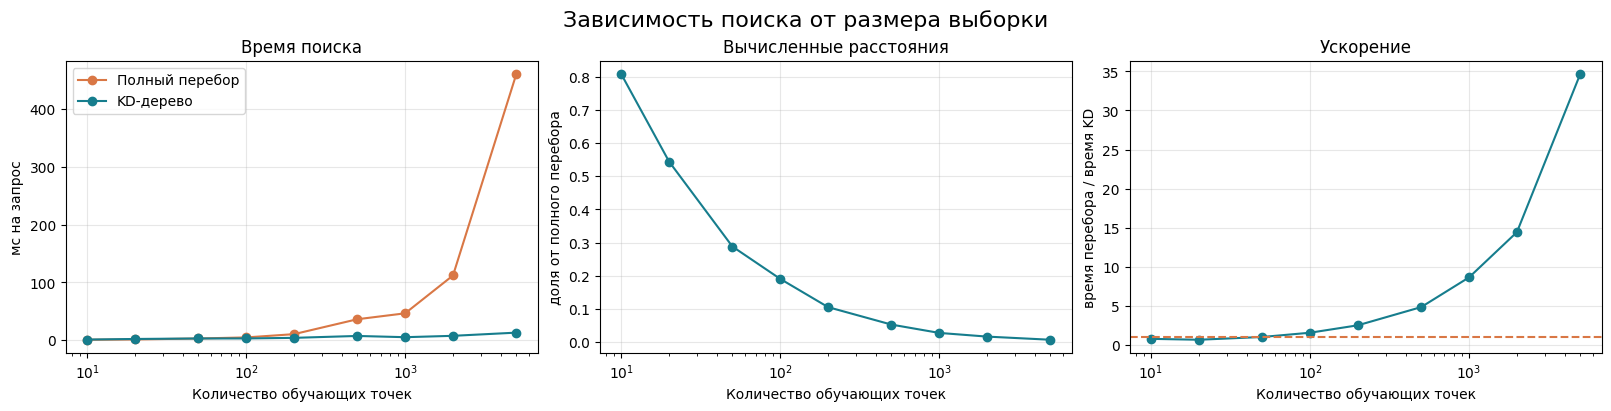

In [6]:
from benchmarks.points_count import POINTS_COUNT, run
from utils.plots import plot_benchmark

results = run()

for result in results:
    boost = result["kd_calculations"] / result["base_calculations"]
    print(
        f'n={result["points_count"]:>4}: '
        f'перебор={result["base_time"] * 1000:>7.3f} мс, '
        f'KD={result["kd_time"] * 1000:>7.3f} мс, '
        f'доля вычисленных расстояний={boost:>7.2%}'
    )

_ = plot_benchmark(
    results,
    x_key="points_count",
    xlabel="Количество обучающих точек",
    title="Зависимость поиска от размера выборки",
    filename="points_count.png",
    log_x=True,
)

## Зависимость от размерности пространства

Перебираем размерность от 1 до 100 и для каждого значения проводим 100 прогонов. Соврешаем несколько запусков и усредняем метрики.

Ожидаем, что с ростом размерности KD-дерево станет посещать большую часть узлов, а выигрыш относительно полного перебора будет уменьшаться.

d= 1: перебор= 82.160 мс, KD=  4.462 мс, доля вычисленных расстояний=  1.34%
d= 2: перебор= 65.775 мс, KD=  4.476 мс, доля вычисленных расстояний=  1.87%
d= 3: перебор= 80.344 мс, KD=  7.248 мс, доля вычисленных расстояний=  2.75%
d= 5: перебор=101.944 мс, KD= 19.373 мс, доля вычисленных расстояний=  5.40%
d=10: перебор= 96.474 мс, KD= 79.738 мс, доля вычисленных расстояний= 22.16%
d=15: перебор= 77.417 мс, KD=119.311 мс, доля вычисленных расстояний= 37.49%
d=20: перебор= 68.746 мс, KD=127.386 мс, доля вычисленных расстояний= 45.72%
d=30: перебор= 64.276 мс, KD=131.969 мс, доля вычисленных расстояний= 50.95%
d=50: перебор= 55.240 мс, KD=129.817 мс, доля вычисленных расстояний= 51.93%
d=100: перебор= 54.446 мс, KD=123.129 мс, доля вычисленных расстояний= 52.11%


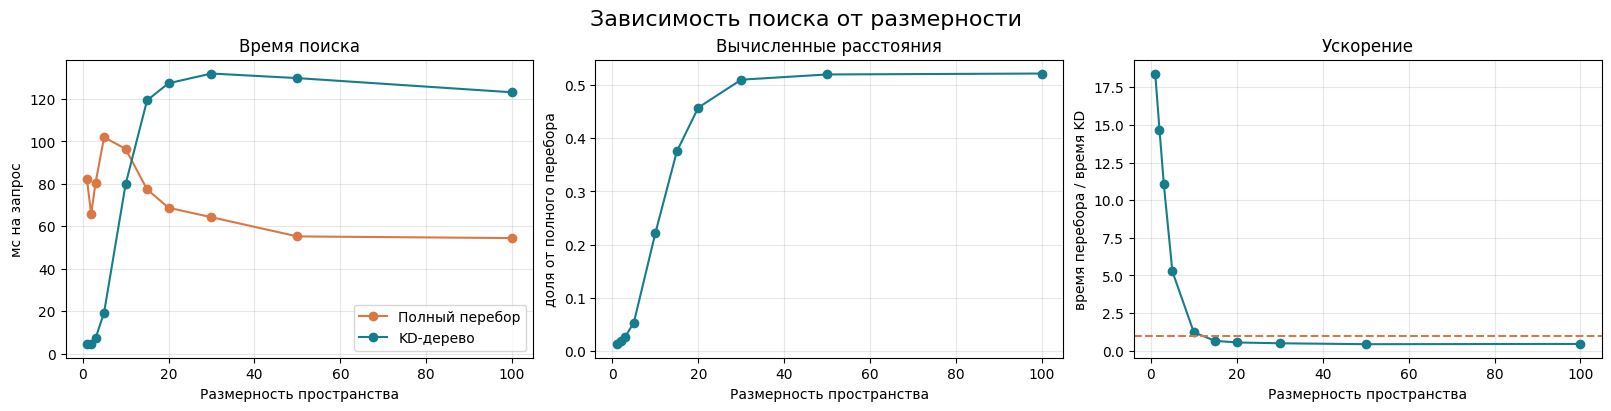

In [7]:
from benchmarks.dimensionality import run as run_dimensionality

dimensionality_results = run_dimensionality()

for result in dimensionality_results:
    calculations_fraction = result["kd_calculations"] / result["base_calculations"]
    print(
        f'd={result["dimensionality"]:>2}: '
        f'перебор={result["base_time"] * 1000:>7.3f} мс, '
        f'KD={result["kd_time"] * 1000:>7.3f} мс, '
        f'доля вычисленных расстояний={calculations_fraction:>7.2%}'
    )

_ = plot_benchmark(
    dimensionality_results,
    x_key="dimensionality",
    xlabel="Размерность пространства",
    title="Зависимость поиска от размерности",
    filename="dimensionality.png",
)

## Зависимость от количества ближайших точек

Число искомых соседей перебираем от 1 до 500. Соврешаем несколько запусков и усредняем метрики.

Чем больше соседей требуется найти, тем больше становится радиус, внутри которого KD-дерево обязано продолжать поиск. Поэтому доля посещённых точек должна расти, а ускорение — уменьшаться.

k=  1: перебор= 34.616 мс, KD=  2.381 мс, доля вычисленных расстояний=  1.35%
k=  3: перебор= 30.117 мс, KD=  2.766 мс, доля вычисленных расстояний=  2.12%
k=  5: перебор= 32.589 мс, KD=  3.659 мс, доля вычисленных расстояний=  2.75%
k= 10: перебор= 36.019 мс, KD=  5.434 мс, доля вычисленных расстояний=  3.99%
k= 20: перебор= 41.808 мс, KD=  8.709 мс, доля вычисленных расстояний=  6.42%
k= 50: перебор= 38.398 мс, KD= 14.300 мс, доля вычисленных расстояний= 12.80%
k=100: перебор= 43.146 мс, KD= 21.914 мс, доля вычисленных расстояний= 20.42%
k=200: перебор= 30.859 мс, KD= 27.168 мс, доля вычисленных расстояний= 38.31%
k=500: перебор= 28.559 мс, KD= 40.121 мс, доля вычисленных расстояний= 74.15%


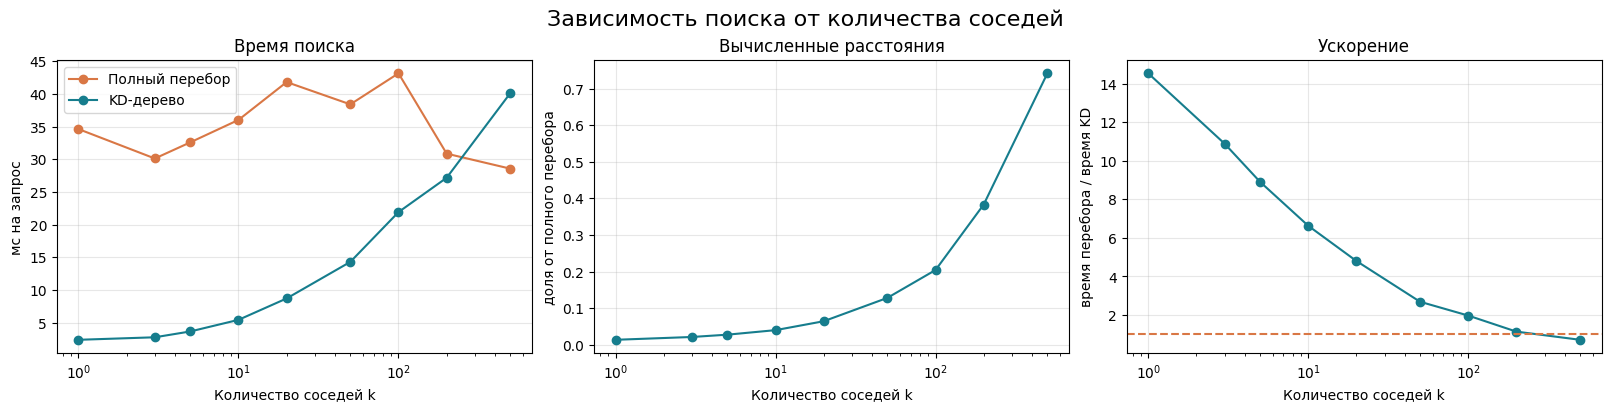

In [8]:
from benchmarks.neighbors_count import run as run_n_neighbors

n_neighbors_results = run_n_neighbors()

for result in n_neighbors_results:
    calculations_fraction = result["kd_calculations"] / result["base_calculations"]
    print(
        f'k={result["k"]:>3}: '
        f'перебор={result["base_time"] * 1000:>7.3f} мс, '
        f'KD={result["kd_time"] * 1000:>7.3f} мс, '
        f'доля вычисленных расстояний={calculations_fraction:>7.2%}'
    )

_ = plot_benchmark(
    n_neighbors_results,
    x_key="k",
    xlabel="Количество соседей k",
    title="Зависимость поиска от количества соседей",
    filename="neighbors_count.png",
    log_x=True,
)

## Зависимость от метрики расстояния

Сравниваем манхэттенское, евклидово и косинусное расстояния, а также несколько Минковских. Соврешаем несколько запусков и усредняем метрики.

Для расстояний Минковского KD-дерево использует расстояние до ограничивающего прямоугольника как нижнюю границу. Для косинусного расстояния такая граница неприменима, поэтому дерево должно проверить все точки и не получить преимущества перед полным перебором.

Манхэттенская       : перебор= 45.438 мс, KD=  5.560 мс, доля вычисленных расстояний=  3.24%
Минковского, p=1.5  : перебор= 48.564 мс, KD=  5.553 мс, доля вычисленных расстояний=  2.86%
Евклидова           : перебор= 47.321 мс, KD=  5.311 мс, доля вычисленных расстояний=  2.75%
Минковского, p=3    : перебор= 36.115 мс, KD=  3.734 мс, доля вычисленных расстояний=  2.63%
Минковского, p=5    : перебор= 37.524 мс, KD=  3.691 мс, доля вычисленных расстояний=  2.57%
Минковского, p=10   : перебор= 29.634 мс, KD=  2.910 мс, доля вычисленных расстояний=  2.54%
Минковского, p=20   : перебор= 37.921 мс, KD=  3.699 мс, доля вычисленных расстояний=  2.55%
Минковского, p=50   : перебор= 35.020 мс, KD=  3.530 мс, доля вычисленных расстояний=  2.55%
Минковского, p=inf  : перебор= 25.171 мс, KD=  2.533 мс, доля вычисленных расстояний=  2.55%
Косинусная          : перебор= 29.818 мс, KD= 32.780 мс, доля вычисленных расстояний=100.00%


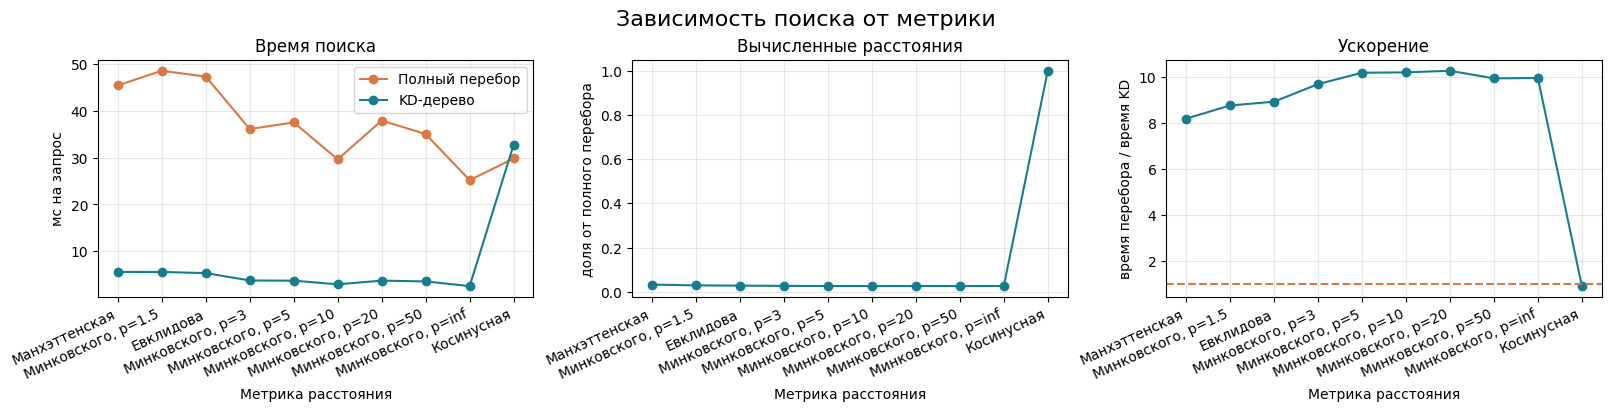

In [9]:
from benchmarks.metrics import run as run_metrics

metrics_results = run_metrics()

for result in metrics_results:
    calculations_fraction = result["kd_calculations"] / result["base_calculations"]
    print(
        f'{result["metric"]:<20}: '
        f'перебор={result["base_time"] * 1000:>7.3f} мс, '
        f'KD={result["kd_time"] * 1000:>7.3f} мс, '
        f'доля вычисленных расстояний={calculations_fraction:>7.2%}'
    )

_ = plot_benchmark(
    metrics_results,
    x_key="metric",
    xlabel="Метрика расстояния",
    title="Зависимость поиска от метрики",
    filename="metrics.png",
    categorical=True,
)

## Выводы

### Количество точек

На маленьких выборках накладные расходы на обход дерева слишком большой, начиная только со 100 точек начинает выигрывать kd-дерево, при этом в дальнейшем отставание только увеличивается. Гипотеза подтвердилась.

### Размерность пространства

При малой размерности kd-дерево очень хорошо отсекает лишние точки, начиная с 10 оно работает уже хуже тупняка. Гипотеза подтвердилась.

### Количество ближайших точек

При $k = 200$ преимущество пропадает (это порядка 1/5 от общего кол-ва точек). Гипотеза подтвердилась.

### Метрика расстояния

С косинусальной всё понятно. А с остальными всё не так однозначно, моё предположение не подтвердилось (хотя казалось, что манхэтонское сильно больше, чем минковского с параметром p=inf). Видимо слишком малый объём точек, но даже так долго гонялся.